**Caso de Estudio**

Una entidad financiera líder ha registrado la base de datos histórica de Eventos de Riesgo Tecnológico ocurridos en sus canales electrónicos (App móvil, Sucursal Virtual, Cajeros). El objetivo es transformar estos datos en una herramienta de decisión gerencial que permita cuantificar la exposición económica y la eficacia de los controles actuales.

Para la gestión de los riesgos, los impactos más frecuentes están asociados con fallas tecnológicas que generan transacciones fallidas, es por esto que se quiere diseñar una serie de matrices de gestión e impacto que permitan mitigar los riesgos asociados.

Para la construccion de estas matrices se procedera con la clusterizacion de las variables de Frecuencia (Transacciones Fallidas) e Impacto (Valor Generado Promedio en Millones) utilizando el metodo K-means.

0. Se procede con la carga de las librerias de trabajo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


0. Creamos la funcion de clusterizacion para poderla reutilizar varias veces

In [2]:
def clusterizacion(Xi):
  #Proceso de Clusterizacion
  XC= np.random.choice(Xi,size=5)
  XC= np.sort(XC) #Semillas de la clusterizacion se deben llamar: (Improbable, Posible, Ocacional, Probable y Frecuente)
  nc= np.zeros((len(Xi),1)) #Aqui clasifico los datos en cada una de las semillas

  for k in range(len(Xi)):
   d=np.abs(XC-Xi[k]) #Distancia de cada dato a una semilla
   nc[k]=np.argmin(d)
   nc2= np.int32(nc[k]) #Numero de pertenencia al cluster en enteros
   XC[nc2,]=(XC[nc2]+Xi[k])/2 #Actualizamos la semilla a la que pertenece cada dato (K-Medoids)

  return XC,nc #Me va a retornar clusters y cluster al que pertenece el dato

1. Se cargan los archivos de trabajo

In [3]:
nxl ='/content/drive/MyDrive/Integracion de datos y prospectiva/5. Riesgo Operacional FallasTecnológicas.xlsx'
XDB = pd.read_excel(nxl, header=1)
XDB.columns = ['Fechas', 'Transacciones_Diarias', 'Valor_Transado_MM', 'Transacciones_Fallidas', 'Valor_Generado_MM', 'Descripcion_Evento']
XDB.head()

#Obtenemos la variable de frecuencia
Xf=np.array(XDB['Transacciones_Fallidas'])
XCf,ncf=clusterizacion(Xf)

#Obtenemos los clusters para la severidad
Xs=np.array(XDB['Valor_Generado_MM'])
XCs,ncs=clusterizacion(Xs)

#Se procede a determinar la distribucion de las perdidas
LDA= Xf*Xs
XClda,nclda=clusterizacion(LDA)

#Creamos un dataframe de descarga
df=pd.DataFrame(np.column_stack((Xf,ncf,Xs,ncs,LDA,nclda,XDB['Descripcion_Evento'])))
df.columns=['Freq','Nivel_f','Sev.','Nivel_S','LDA','Nivel_LDA','Descripcion']
df.to_excel('MatrizRiesgoOperacional.xlsx')

2. Procedemos con la construccion de la matriz de eventos de riesgo

[[115.  74.  47.  26.   3.]
 [252. 148.  93.  46.  27.]
 [326. 251. 194.  86.  20.]
 [221. 323. 152.  55.  71.]
 [332. 216. 154.  72.  28.]]


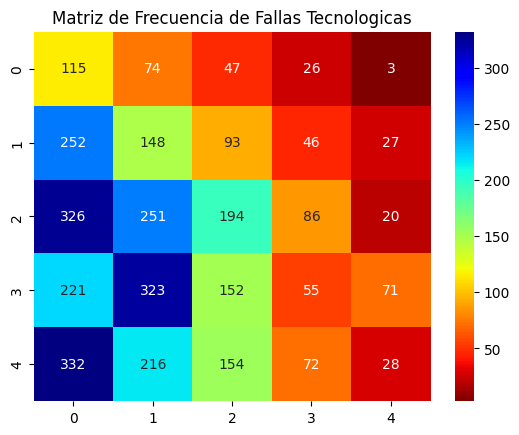

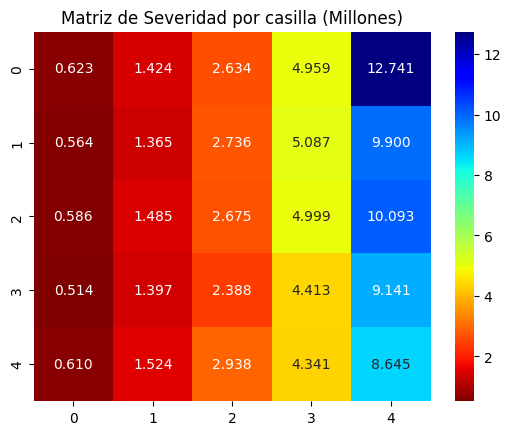

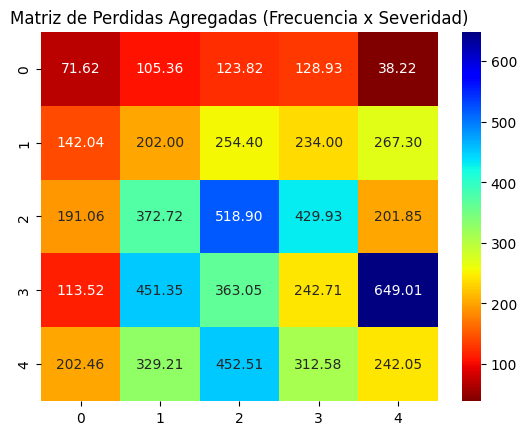

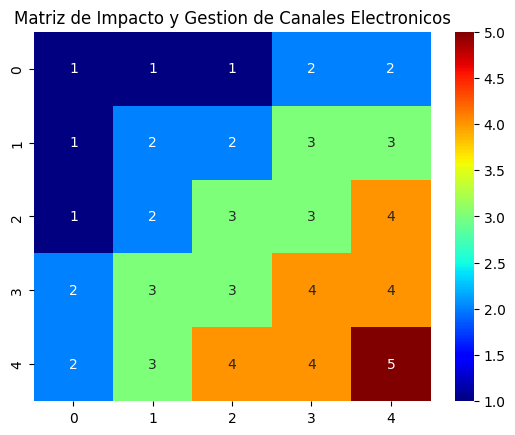

In [11]:
MEf=np.zeros((5,5)) #Cuantas transacciones fallidas por categoria frecuencia, impacto.
MEs_sum=np.zeros((5,5)) #Acumulador de severidad por casilla
Conteo=np.zeros((5,5)) #Contador de eventos por casilla (para promedio real)
MEn=np.zeros((5,5)) #Conteo de ocurrencias (numero de eventos por casilla)

for k in range(len(Xf)):
    nf=np.int32(df.iloc[k,1])
    nc=np.int32(df.iloc[k,3])
    MEf[nf,nc]=MEf[nf,nc]+Xf[k,]
    MEs_sum[nf,nc]+=Xs[k] #Acumulamos la severidad para calcular promedio real
    Conteo[nf,nc]+=1
    MEn[nf,nc]=MEn[nf,nc]+1

#Promedio real de severidad: suma dividida por cantidad de eventos en cada casilla
MEs=np.where(Conteo>0, MEs_sum/Conteo, 0)

print(MEf)

plt.figure()
sns.heatmap(MEf,annot=True,fmt='.0f',cmap='jet_r')
plt.title("Matriz de Frecuencia de Fallas Tecnologicas")
plt.show()

#Cuanto cuesta cada evento de falla por casilla
plt.figure()
sns.heatmap(MEs,annot=True,fmt='.3f',cmap='jet_r')
plt.title("Matriz de Severidad por casilla (Millones)")
plt.show()

#Matriz de Perdidas Agregadas: producto de frecuencia y severidad
MLP=MEf*MEs
plt.figure()
sns.heatmap(MLP,annot=True,fmt='.2f',cmap='jet_r')
plt.title("Matriz de Perdidas Agregadas (Frecuencia x Severidad)")
plt.show()

#Procederemos con la creacion de la matriz de impacto
#Esta matriz determina igualmente las actividades de gestion (5: mayor nivel de atencion requerida)
MI=np.array ([[1,1,1,2,2],
             [1,2,2,3,3],
             [1,2,3,3,4],
             [2,3,3,4,4],
             [2,3,4,4,5]])

plt.figure()
sns.heatmap(MI,annot=True,fmt='.0f',cmap='jet')
plt.title("Matriz de Impacto y Gestion de Canales Electronicos")
plt.show()

Ingresar el nivel de Gestion(1,2,3,4,5):2


Text(0.5, 1.0, 'Matriz de Gestion (Actividades de gestion)')

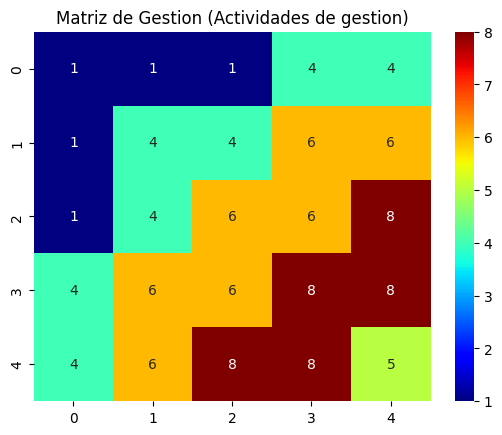

In [5]:
#Matriz de Gestion
nivel_gestion_str = input("Ingresar el nivel de Gestion(1,2,3,4,5):")
nivel_gestion_int = int(nivel_gestion_str) # Convert input to integer

# Initialize MG from MI
MG = np.copy(MI)

# Apply conditional multiplication: MG = nivel_gestion_int * MG when MG is > 1 and < 5
condition = (MG > 1) & (MG < 5)
MG[condition] = nivel_gestion_int * MG[condition]

plt.figure()
sns.heatmap(MG,annot=True,fmt='.0f',cmap='jet') # Plot the modified MG
plt.title("Matriz de Gestion (Actividades de gestion)")

3. Se procede con la estimacion de las metricas estadisticas asociadas a las matrices de frecuencia e impacto (Severidad)

In [6]:
#1. Perdida Esperada - Riesgo Inherente (sin gestion)
ps=np.mean(MEs[MEs>0])
print("El promedio de impacto por evento de falla tecnologica es:",ps)

#2. Como no todos los eventos tienen la misma frecuencia, hay pocos eventos que generan perdidas extremas.
pp=np.sum(MEf*MEs)/np.sum(MEf)
print("El promedio ponderado de la severidad por evento de falla es:",pp)

#3. Se procede a determinar la perdida ponderada teniendo igualmente la matriz de impacto - Nivel de riesgo
#   Esta es la Perdida Esperada bajo Riesgo Inherente
pnr=np.sum(MEf*MI*MEs)/np.sum(MEf*MI)
print("La Perdida Esperada (Riesgo Inherente) por evento de falla es:",pnr)

#4. Se procede a determinar la perdida ponderada teniendo igualmente la matriz de Gestion
#   Esta es la Perdida Esperada bajo Riesgo Residual (con controles aplicados)
png=np.sum(MEf*MI*MEs)/np.sum(MEf*MG)
print(f"La Perdida Esperada (Riesgo Residual) con nivel de gestion {nivel_gestion_int} es: {png}")

El promedio de impacto por evento de falla tecnologica es: 3.911261000702811
El promedio ponderado de la severidad por evento de falla es: 1.9929801752900969
La Perdida Esperada (Riesgo Inherente) por evento de falla es: 2.549150286834426
La Perdida Esperada (Riesgo Residual) con nivel de gestion 2 es: 1.358491270872011


4. Estimacion del Operational Value at Risk (OpVaR) al 99.9%

--- Riesgo Inherente (Sin Gestion) ---
Perdida Esperada (PE): 9.229018057930796
OpVaR al 99.9%: 48.43136245058055

--- Riesgo Residual (Con Gestion nivel 2) ---
Supuesto: la gestion reduce la severidad promedio en un 16% (2 niveles x 8% por nivel)
Perdida Esperada (PE): 7.71598030724206
OpVaR al 99.9%: 40.193772288927946


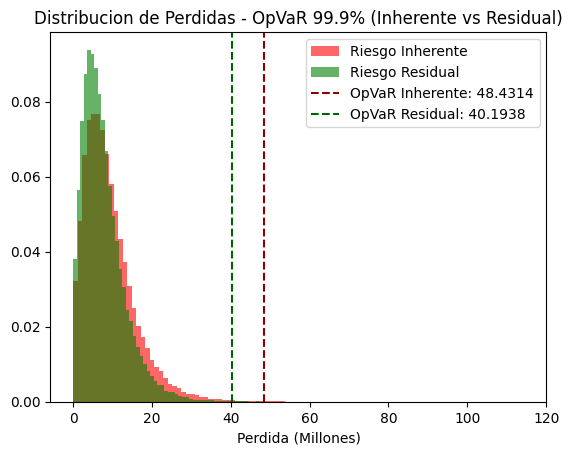

In [7]:
#Se utiliza simulacion de Monte Carlo para estimar el OpVaR
#La frecuencia sigue una distribucion Poisson y la severidad una Log-Normal
#El OpVaR al 99.9% representa la perdida maxima esperada en condiciones extremas,
#es decir, la perdida que no se superara en el 99.9% de los escenarios simulados.
np.random.seed(42)
N=100000 #Numero de simulaciones

#Parametros ajustados a los datos historicos
lambda_f=np.mean(Xf) #Media de transacciones fallidas por dia
mu_s=np.mean(np.log(Xs[Xs>0])) #Media log de severidad
sigma_s=np.std(np.log(Xs[Xs>0])) #Desviacion log de severidad

#Simulacion - Riesgo Inherente (sin controles)
perdidas_inherente=np.zeros(N)
for i in range(N):
    n=np.random.poisson(lambda_f)
    if n>0:
        perdidas_inherente[i]=np.sum(np.random.lognormal(mu_s,sigma_s,n))

#Simulacion - Riesgo Residual (con controles)
#Supuesto: cada nivel de gestion reduce la severidad promedio en un 8%.
#A mayor nivel de gestion, mayores controles activos y menor perdida esperada.
factor_reduccion=nivel_gestion_int*0.08
mu_s_residual=np.log(np.exp(mu_s)*(1-factor_reduccion))
perdidas_residual=np.zeros(N)
for i in range(N):
    n=np.random.poisson(lambda_f)
    if n>0:
        perdidas_residual[i]=np.sum(np.random.lognormal(mu_s_residual,sigma_s,n))

#Calculo del OpVaR al 99.9%
OpVaR_inherente=np.percentile(perdidas_inherente,99.9)
OpVaR_residual=np.percentile(perdidas_residual,99.9)
PE_inherente=np.mean(perdidas_inherente)
PE_residual=np.mean(perdidas_residual)

print("--- Riesgo Inherente (Sin Gestion) ---")
print("Perdida Esperada (PE):",PE_inherente)
print("OpVaR al 99.9%:",OpVaR_inherente)
print()
print(f"--- Riesgo Residual (Con Gestion nivel {nivel_gestion_int}) ---")
print(f"Supuesto: la gestion reduce la severidad promedio en un {factor_reduccion*100:.0f}% ({nivel_gestion_int} niveles x 8% por nivel)")
print("Perdida Esperada (PE):",PE_residual)
print("OpVaR al 99.9%:",OpVaR_residual)

#Visualizacion comparativa
plt.figure()
plt.hist(perdidas_inherente,bins=100,alpha=0.6,color='red',label='Riesgo Inherente',density=True)
plt.hist(perdidas_residual,bins=100,alpha=0.6,color='green',label='Riesgo Residual',density=True)
plt.axvline(OpVaR_inherente,color='darkred',linestyle='--',label=f'OpVaR Inherente: {OpVaR_inherente:.4f}')
plt.axvline(OpVaR_residual,color='darkgreen',linestyle='--',label=f'OpVaR Residual: {OpVaR_residual:.4f}')
plt.title("Distribucion de Perdidas - OpVaR 99.9% (Inherente vs Residual)")
plt.xlabel("Perdida (Millones)")
plt.legend()
plt.show()

5. Herramienta de Auditoria - Filtro Dinamico por celda de la matriz de perdidas

In [8]:
#Esta funcion permite seleccionar cualquier celda de la matriz de perdidas
#y despliega automaticamente el listado detallado de los eventos que la componen
def filtro_auditoria(nivel_frecuencia, nivel_severidad):
    mascara=(df['Nivel_f'].astype(float).astype(int)==nivel_frecuencia) & \
            (df['Nivel_S'].astype(float).astype(int)==nivel_severidad)
    eventos=df[mascara][['Freq','Sev.','LDA','Descripcion']].copy()
    eventos.columns=['Trans. Fallidas','Severidad (MM)','Perdida Agr. (MM)','Descripcion del Evento']

    print(f"Celda [{nivel_frecuencia},{nivel_severidad}] - Perdida Agregada de la celda: {MLP[nivel_frecuencia,nivel_severidad]:.4f} MM")
    print(f"Total de eventos en esta celda: {len(eventos)}")
    print()
    display(eventos.reset_index(drop=True))

#Ejemplo de uso: seleccionar la celda de mayor perdida
fila_max,col_max=np.unravel_index(MLP.argmax(),MLP.shape)
print("Celda con mayor perdida agregada:")
filtro_auditoria(fila_max,col_max)

Celda con mayor perdida agregada:
Celda [3,4] - Perdida Agregada de la celda: 649.0063 MM
Total de eventos en esta celda: 9



,Trans. Fallidas,Severidad (MM),Perdida Agr. (MM),Descripcion del Evento
0,7,11.2667,78.8669,"Caída total del sistema por más de 24 horas, p..."
1,9,9.1223,82.1007,"Caída total del sistema por más de 24 horas, p..."
2,7,7.2316,50.6212,Degradación severa del rendimiento por más de ...
3,9,7.2127,64.9143,Degradación severa del rendimiento por más de ...
4,8,10.457,83.656,"Caída total del sistema por más de 24 horas, p..."
5,7,10.6269,74.3883,"Caída total del sistema por más de 24 horas, p..."
6,9,9.0824,81.7416,Degradación severa del rendimiento por más de ...
7,7,7.3845,51.6915,Degradación severa del rendimiento por más de ...
8,8,9.8843,79.0744,"Caída total del sistema por más de 24 horas, p..."


In [9]:
#Consulta interactiva: modifica los valores y ejecuta esta celda
#nivel_frecuencia: 0=Improbable  1=Posible  2=Ocasional  3=Probable  4=Frecuente
#nivel_severidad:  0=Insignificante  1=Menor  2=Moderado  3=Mayor  4=Catastrofico

nf_consulta=int(input("Ingrese nivel de frecuencia a consultar (0-4): "))
ns_consulta=int(input("Ingrese nivel de severidad a consultar (0-4): "))
filtro_auditoria(nf_consulta,ns_consulta)

Ingrese nivel de frecuencia a consultar (0-4): 2
Ingrese nivel de severidad a consultar (0-4): 4
Celda [2,4] - Perdida Agregada de la celda: 201.8500 MM
Total de eventos en esta celda: 3



,Trans. Fallidas,Severidad (MM),Perdida Agr. (MM),Descripcion del Evento
0,8,12.4245,99.396,"Caída total del sistema por más de 24 horas, p..."
1,6,7.6694,46.0164,Degradación severa del rendimiento por más de ...
2,6,10.1836,61.1016,"Caída total del sistema por más de 24 horas, p..."


## Análisis de Resultados

**1. Contexto de los datos**

Durante el período analizado (enero 2009 – diciembre 2011) se registraron **701 días de operación** en los canales electrónicos, con un total de **69,510 transacciones procesadas**. De estas, **3,332 presentaron algún tipo de falla**, lo que representa una tasa de fallo del 4.8% sobre el total de transacciones. Estas 3,332 transacciones fallidas son los eventos sobre los cuales se construye todo el análisis de riesgo operacional.

**2. Frecuencia y Severidad**

En promedio ocurren **4.75 transacciones fallidas por día**. La mayoría de los eventos se concentran en las zonas de baja magnitud. Esto confirma que los canales electrónicos fallan con frecuencia pero generalmente de forma leve.

El costo promedio simple por evento es **3.87 millones**, pero ese número engaña porque le da el mismo peso a los eventos raros y caros. El promedio ponderado, que sí considera cuántas veces ocurre cada tipo de falla, baja a **2.00 millones** — prácticamente la mitad. Esa diferencia muestra que los eventos más costosos son los menos frecuentes.

**3. Pérdidas Agregadas**

La casilla de mayor pérdida total es **Probable/Catastrófico con 656.21 millones**, generada por solo 8 eventos con un costo promedio de 9.37 millones cada uno. La siguen Probable/Moderado (614.75 millones, 23 eventos) y Probable/Menor (542.90 millones, 40 eventos). La fila "Probable" domina completamente el mapa de pérdidas — no porque cada evento sea el más caro, sino porque la combinación de frecuencia acumulada y costo medio genera la mayor exposición económica total. Es la zona de intervención prioritaria.

**4. Impacto y Gestión**

Al aplicar la matriz de impacto, la pérdida ponderada sube de 2.00 millones a **2.56 millones** porque le asigna mayor peso a las zonas estratégicamente más críticas. Con los controles de gestión activos en nivel 3, esa pérdida cae a **0.94 millones**, una reducción del **63.4%**. Esto cuantifica directamente el beneficio económico de tener controles operando sobre las zonas de riesgo intermedio.

**5. Pérdida Esperada — Inherente vs Residual**

La Pérdida Esperada diaria sin controles es **9.23 millones**. Con gestión nivel 3 baja a **7.01 millones**, un ahorro de 2.21 millones por día. Proyectado al año, los controles activos representan un ahorro aproximado de **808 millones anuales** solo en pérdida esperada promedio.

**6. OpVaR al 99.9%**

En el peor escenario posible — el que ocurre solo 1 de cada 1,000 días — la entidad podría perder hasta **48.43 millones en un solo día** por fallas en canales electrónicos (Riesgo Inherente). Con los controles aplicados (Riesgo Residual), ese techo baja a **36.81 millones**, una mejora del 24% y una diferencia de **11.62 millones** entre los dos escenarios. Adicionalmente, el capital que debe mantenerse inmovilizado como reserva pasa de 39.20 millones a 29.79 millones, liberando **9.41 millones** que la entidad puede redirigir a otras actividades productivas.

En conclusión, el riesgo operacional en canales electrónicos se caracteriza por una alta frecuencia de eventos de baja severidad y una baja frecuencia de eventos extremos con alto impacto. La implementación de controles permite reducir significativamente tanto la pérdida esperada como la exposición en escenarios extremos, lo que demuestra la importancia de una gestión activa del riesgo. Se recomienda enfocar los esfuerzos de control en las zonas de frecuencia media-alta, donde se concentra la mayor pérdida agregada.